
# Project Milestone One: Forming Your Team, Understanding the Problem, and Exploring the Data

#### **Due:** Midnight on March 29th (with 2-hour grace period) — **worth 25 points**

> **Note:** Because we must begin manual grading immediately, there will be *no* late period for this milestone. 

This milestone is the first phase of your project. You’ll begin working in teams, select your dataset, perform basic exploratory data analysis (EDA), and frame your classification problem.  

1. **Form your project team.**  
   Convene your team and complete the **Team Contract** (available in your Homework Repository). This is **due on Sunday, March 22nd** at midnight (along with Homework 07). Each member must review and sign it before submission.

2. **Select a team leader.**  
   Choose one team member to act as the **Gradescope submitter** for your team. The entire team should collaborate on the notebook, but only the leader will submit.

3. **Explore your dataset and frame your task.**  
   You’ll work through the notebook to  
   - Examine both provided datasets,  
   - Choose one for your project,
   - Be able to describe the classification problem you’ll be solving in business or applied terms, 
   - Conduct basic EDA to understand its structure and challenges, and
   - Spot potential challenges, propose solutions, and select appropriate performance metrics.  

This milestone focuses on understanding your data and clearly articulating what your model will eventually predict. You are not required to build a model yet (that will happen in Milestone 2) but of course you have lots of example models to choose from previous Homeworks and Coding Notebooks and you may wish to explore a baseline model as you do this first phase of your project. 


### The Datasets

The final project is a **classification task** using **one of two datasets**—one image-based and one text-based. These are the two
domains we have studied in detail, after learning the fundamentals in the first three weeks, and you have all you need to approach either of these datasets with confidence. 

#### **1. Food-101 (Images)**  
A web-scraped collection of approximately **101,000 color photos** across **101 food categories** (≈ 800 train / 100 validation / 100 test per class).  
Images vary widely in **lighting, composition, and color balance**, making this dataset excellent for practicing **data cleaning**, **EDA**, and **augmentation** techniques such as random crops, flips, and color jitter. 

#### **2. HuffPost News Category (Text)**  
Roughly **200,000 short news items** labeled into **41 topical categories** (e.g., *POLITICS*, *ENTERTAINMENT*, *PARENTING*).  
Each record contains a **headline**, a **short description**, which we will concatenate with a separator token to make a single text string: 
> `"headline [SEP] short_description"`.
> 
The `[SEP]` token simply marks where the headline ends and the description begins—mirroring conventions used in transformer models such as BERT.


### What To Do


We’ve provided template code to start your project:

* **Download** your selected dataset.
* **Visualize** a few representative samples (images or text excerpts).

After reviewing both datasets, you’ll **choose one** for your semester project.

In the sections that follow:

* **Problem One — Exploratory Data Analysis (EDA):**
  Quantify scale and structure, check class balance, and note any missing/duplicate or inconsistent entries.

* **Problem Two — Challenges & Solution Paths:**
  Identify likely issues (e.g., overlapping categories, imbalanced labels, data-quality problems, length/size variance) and outline practical remedies you would try. *(No model training required.)*

For tips on working with **Hugging Face Datasets** (helpful for large datasets), see the **Appendix**.

> **Important:** Keep only the section for the dataset you select and delete the other before submitting **Milestone 1**.


In [1]:
# ============================================
# Useful Imports
# ============================================

# --- Standard Libraries
import os
import time
import math
import random
from collections import Counter

# --- Core Data / Numerics
import numpy as np
import pandas as pd

# --- Visualization
import matplotlib.pyplot as plt
# import seaborn as sns              # optional
import matplotlib.ticker as mticker  # optional (for formatted axes)

# --- NLP / Tokenization
import spacy                         # used for text preprocessing (HuffPost)

# --- Progress Tracking
from tqdm import tqdm                # optional (nice for loops)

from IPython.display import display

# --- TensorFlow / Keras (Deep Learning)
import tensorflow as tf
from tensorflow.keras import layers, models, Input, callbacks, regularizers, initializers
from tensorflow.keras.callbacks import Callback, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam, AdamW
from tensorflow.keras.optimizers.schedules import CosineDecay, ExponentialDecay
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.layers import (
    Dense, Dropout, Flatten, MaxPooling2D, Conv2D,
    SeparableConv2D, GlobalAveragePooling2D, GlobalMaxPooling2D, BatchNormalization
)

# --- (Optional) Classical ML Baseline Tools
# from sklearn.pipeline import Pipeline
# from sklearn.feature_extraction.text import TfidfVectorizer
# from sklearn.linear_model import LogisticRegression
# from sklearn.metrics import accuracy_score


# ============================================
# Global Configuration & Small Utilities
# ============================================

# Reproducibility
random_seed = 42
random.seed(random_seed)
np.random.seed(random_seed)
tf.keras.utils.set_random_seed(random_seed)   # sets Python, NumPy, and TensorFlow seeds

# Utility: format seconds as HH:MM:SS

"""
Example usage to time your code:

start_time = time.time()
# ... your code here ...
print("Execution Time:", format_hms(time.time() - start_time))
"""

def format_hms(seconds: float) -> str:
    """Convert seconds to HH:MM:SS format."""
    return time.strftime("%H:%M:%S", time.gmtime(seconds))


In [2]:
# If needed (in a new env):
!pip install -U datasets pillow

In [3]:
# --- Hugging Face Datasets
from datasets import load_dataset, DatasetDict
from datasets.features import ClassLabel

## Prelude: Choose your dataset and take a first look

You’ll pick **one** dataset—either **Food-101 (images)** or **HuffPost (text)**—and run the starter cells to confirm it loads, view class stats, and skim a few samples.

* **Food-101 (images):** 101 classes of web photos with **inconsistent lighting, white balance, color casts, and composition** (plus varying resolutions). These natural quirks make augmentation and input-pipeline choices meaningful.
* **HuffPost (text):** ~200k headline/summary pairs across 41 topics with **class imbalance** and some **category overlap**—good for trying stratified splits and reporting macro-F1 in addition to accuracy.

After you review the two sections below (download → minimal EDA → split), **keep one and delete the other.** Stick with your choice for the entire project.

> **Note:** We use Hugging Face **Dataset/DatasetDict** objects (table-like datasets), not NumPy/Pandas arrays. Most of what you need to know is contained in the template code, but see the **Appendix** for more information on HG Datasets. 


---

### Dataset One (Images): Food-101

#### **Load Food-101 as a Dataset**

> Note: this loads a **Hugging Face `Dataset`**, not NumPy or TensorFlow tensors.
> Each sample is stored as a **dictionary** with two keys — `"image"` (a PIL image object) and `"label"` (an integer class ID).
> You can access columns by name, e.g. `food_all["image"]` or `food_all["label"]`, and check the dataset size with `len(food_all)`.
> Unlike arrays, image sizes and aspect ratios may differ across samples — you’ll handle resizing or normalization later during preprocessing.


In [4]:
food_all = load_dataset("food101", split="train+validation")  # ~101k images total
label_col = "label"

# Sanity check the label column
assert label_col in food_all.features
assert isinstance(food_all.features[label_col], ClassLabel)

food_label_names = food_all.features[label_col].names
print(f"Total images: {len(food_all):,}  |  Classes: {len(food_label_names)}")

Total images: 101,000  |  Classes: 101


#### **Quick sanity checks (rows, label ids, a few image sizes)**

In [5]:
# First 5 rows: label id → name
for i in range(5):
    y = food_all[i][label_col]
    print(f"row {i}: id={y}, name={food_label_names[y]}")

labels_list = list(food_all[label_col])
print("labels length:", len(labels_list), "unique classes:", len(set(labels_list)))
print("min/max label IDs:", min(labels_list), max(labels_list))

for i in range(3):
    print(f"image {i} size:", food_all[i]["image"].size)  # (W, H)

row 0: id=6, name=beignets
row 1: id=6, name=beignets
row 2: id=6, name=beignets
row 3: id=6, name=beignets
row 4: id=6, name=beignets
labels length: 101000 unique classes: 101
min/max label IDs: 0 100
image 0 size: (384, 512)
image 1 size: (512, 512)
image 2 size: (512, 383)


#### **Visual preview: random 3×3 grid from TRAIN**

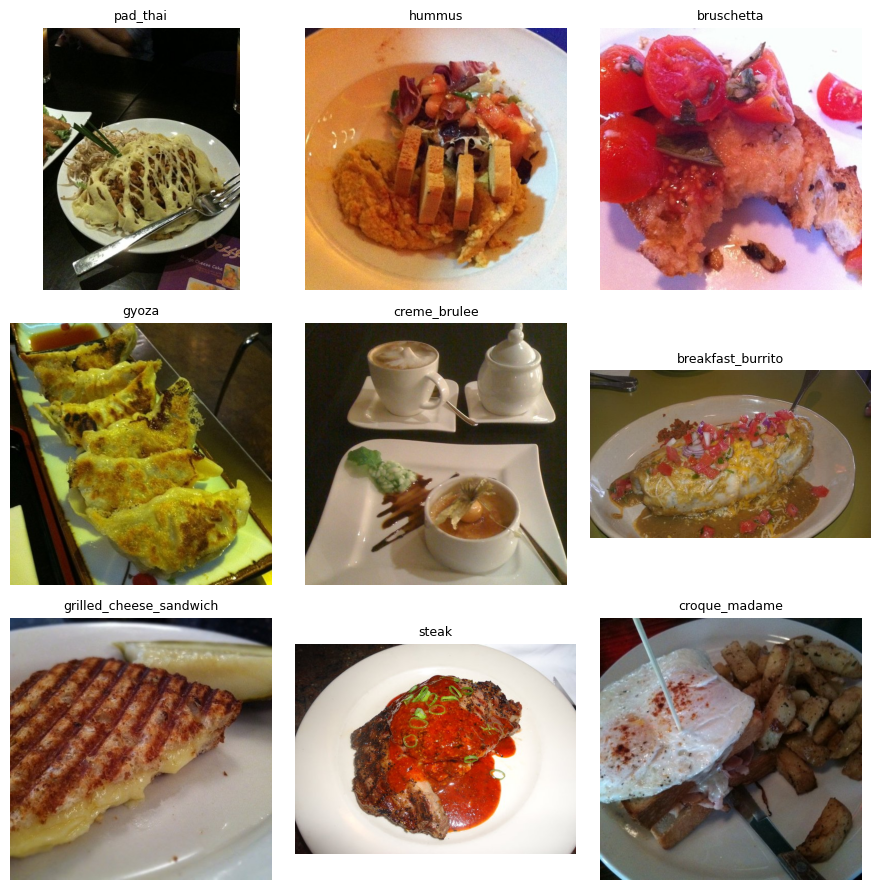

In [6]:
n, cols, seed = 9, 3, 42
idxs = random.Random(seed).sample(range(len(food_all)), n)
rows = math.ceil(n/cols)

plt.figure(figsize=(3*cols, 3*rows))
for i, idx in enumerate(idxs, 1):
    ex = food_all[idx]
    plt.subplot(rows, cols, i)
    plt.imshow(ex["image"]); plt.axis("off")
    plt.title(food_label_names[ex[label_col]], fontsize=9)
plt.tight_layout(); plt.show()

---

### Dataset Two (Text): HuffPost Dataset

#### **Load HuffPost (headline + summary + category)**

**Note:** This loads a **Hugging Face `Dataset`**, not a NumPy array or Pandas DataFrame.
- Each record is a **dictionary** with fields such as `"headline"`, `"short_description"`, and `"category"`.
- You can access columns by name (e.g., `huff["headline"]`) and check dataset size with `len(huff)`.
- Treat it as a table of text fields — you’ll handle tokenization and vectorization later during preprocessing.
- The typical BERT-compatible separator is used to construct the sample texts

        `headline [SEP] short-description`



In [7]:
# JSON mirror that preserves fields: headline, short_description, category, authors, link, date
URL = "https://huggingface.co/datasets/khalidalt/HuffPost/resolve/main/News_Category_Dataset_v2.json"
huff_all = load_dataset("json", data_files=URL, split="train")

print(huff_all)
print("Columns:", huff_all.column_names)
print("Total rows:", len(huff_all))

Dataset({
    features: ['category', 'headline', 'authors', 'link', 'short_description', 'date'],
    num_rows: 200853
})
Columns: ['category', 'headline', 'authors', 'link', 'short_description', 'date']
Total rows: 200853


#### **Quick sanity checks (peek at a row)**

In [8]:
ex.keys()

dict_keys(['image', 'label'])

In [9]:
ex = huff_all[0]
print("One example:")
print("  category          :", ex.get("category"))
print("  headline          :", (ex.get("headline") or "")[:120])
print("  authors           :", (ex.get("authors") or "")[:120])
print("  short_description :", (ex.get("short_description") or "")[:120])
print("  date              :", ex.get("date"))

One example:
  category          : CRIME
  headline          : There Were 2 Mass Shootings In Texas Last Week, But Only 1 On TV
  authors           : Melissa Jeltsen
  short_description : She left her husband. He killed their children. Just another day in America.
  date              : 2018-05-26 00:00:00


#### **Print 10 random samples (combined text with separator, no truncation)**

In [10]:
# Show k random lines: "headline [SEP] short_description"

k = 10
seed = 7
rng = random.Random(seed)
idxs = rng.sample(range(len(huff_all)), k)

for i in idxs:
    ex = huff_all[i]
    print("  category          :", ex.get("category"))
    print("  headline          :", (ex.get("headline") or ""))
    print("  short_description :", (ex.get("short_description") or ""))
    print("  sample text       :", (ex.get("headline") or "")+'  [SEP]  '+ (ex.get("short_description") or ""))
    print()

  category          : ENTERTAINMENT
  headline          : Pregnant Kim Kardashian Rocks A Sheer Jumpsuit At The Airport
  short_description : Forget what you thought you knew about maternity style, because Kim's changing the game.
  sample text       : Pregnant Kim Kardashian Rocks A Sheer Jumpsuit At The Airport  [SEP]  Forget what you thought you knew about maternity style, because Kim's changing the game.

  category          : WOMEN
  headline          : How I Outran Misogyny
  short_description : "I have started running to retrain the way my brain sees my body, not as a sexual object but as a tool to get things done."
  sample text       : How I Outran Misogyny  [SEP]  "I have started running to retrain the way my brain sees my body, not as a sexual object but as a tool to get things done."

  category          : RELIGION
  headline          : A Prayer From the Mall of America
  short_description : I thank you for the Bloomington Police Department, and the Mall of America Security

#### **(Optional) Save splits to disk (reload later without re-splitting)**

We provide this in case you want to save the dataset to your local disk. Saving Food-101 splits to disk is not recommended unless you have ample local storage (it's huge!). 

In [11]:
huff_all.save_to_disk("huffpost_splits")        # save
from datasets import load_from_disk
huff_all = load_from_disk("huffpost_splits")  # reload when needed

Saving the dataset (0/1 shards):   0%|          | 0/200853 [00:00<?, ? examples/s]

---

## Problem 1 – Choose the Dataset (10 pts)

#### Objective
In this problem, you will explore the two provided datasets and select one to use for your final project.  
Your goal is to understand the structure, content, and challenges of the dataset through basic exploratory data analysis (EDA).  
By the end of this Milestone notebook, you should be able to explain what makes the dataset interesting, identify potential modeling challenges (e.g., imbalance, ambiguity, quality issues), and justify why it is a good choice for your classification project.


#### What to Do
1. **Load both datasets** and examine the outputs of the template code provided.  
   After this brief inspection, **choose one dataset for your project** and **delete the template code for the other.**  For your chosen dataset, continue with the remaining steps.

2. **Inspect** the dataset's basic properties:  
   - **Number of samples and classes:**  
     Determine how many total examples and distinct categories are present. Verify that the counts match expectations (e.g., 101 food classes or 41 news topics).  
   - **Example records or images:**  
     View several samples to understand the input format, diversity, and potential quality issues.  
     For images, note lighting or composition differences; for text, read a few headlines and summaries to see how expressive they are (done for you in template code). 
   - **Distribution of labels (check for imbalance):**  
     Plot or tabulate label frequencies to see whether some classes dominate. Imbalanced datasets can bias model training and may require special handling.  
   - **Missing or inconsistent data:**  
     Look for empty fields, unreadable images, duplicate entries, or mislabeled samples. Handle or document any issues you find.  
   - **Overlapping or ambiguous class labels:**  
     Identify categories that may not be clearly distinct—e.g., “apple pie” vs. “cheesecake,” or “POLITICS” vs. “WORLD NEWS.”  
     Ambiguity in labels can increase confusion between classes and reduce model accuracy.

3. **Visualize key aspects:**  
   Extend the template code to complete the EDA for your chosen dataset:  
   - **Images:**  
     Create visual summaries to better understand the data (some are implemented in the template code).  
     - Verify that the dataset is balanced across classes.  
     - Display a small grid of random images to check variation in appearance, composition, and background (done in template code).  
     - Compare image sizes to determine whether resizing or normalization will be needed.  
     - Examine lighting and color balance—many web-scraped photos vary widely in brightness, saturation, and white balance.  
   - **Text:**  
     Visualize class balance and linguistic properties (some implemented in the template code).  
     - Plot the number of samples per label to confirm class balance or imbalance.  
     - Compute basic text statistics such as average word count or vocabulary size.  
     - Examine examples for duplicates, near-duplicates, or entries that might fit multiple categories.  
     - *(Optional)* Generate a word-frequency plot or word cloud to highlight distinctive terms for a few classes.

4. **Answer the graded questions below.**


Total articles: 200853
Unique categories: 41
Categories: {'WOMEN', 'FIFTY', 'MONEY', 'SCIENCE', 'ENTERTAINMENT', 'ARTS & CULTURE', 'IMPACT', 'COMEDY', 'RELIGION', 'PARENTING', 'GOOD NEWS', 'BUSINESS', 'ARTS', 'HEALTHY LIVING', 'FOOD & DRINK', 'WELLNESS', 'LATINO VOICES', 'TECH', 'GREEN', 'EDUCATION', 'DIVORCE', 'WEIRD NEWS', 'QUEER VOICES', 'COLLEGE', 'ENVIRONMENT', 'TASTE', 'STYLE', 'STYLE & BEAUTY', 'THE WORLDPOST', 'CRIME', 'HOME & LIVING', 'WORLDPOST', 'BLACK VOICES', 'WORLD NEWS', 'POLITICS', 'MEDIA', 'CULTURE & ARTS', 'PARENTS', 'WEDDINGS', 'TRAVEL', 'SPORTS'}
Article counts by category:
  POLITICS: 32739
  WELLNESS: 17827
  ENTERTAINMENT: 16058
  TRAVEL: 9887
  STYLE & BEAUTY: 9649
  PARENTING: 8677
  HEALTHY LIVING: 6694
  QUEER VOICES: 6314
  FOOD & DRINK: 6226
  BUSINESS: 5937
  COMEDY: 5175
  SPORTS: 4884
  BLACK VOICES: 4528
  HOME & LIVING: 4195
  PARENTS: 3955
  THE WORLDPOST: 3664
  WEDDINGS: 3651
  WOMEN: 3490
  IMPACT: 3459
  DIVORCE: 3426
  CRIME: 3405
  MEDIA: 2815
 

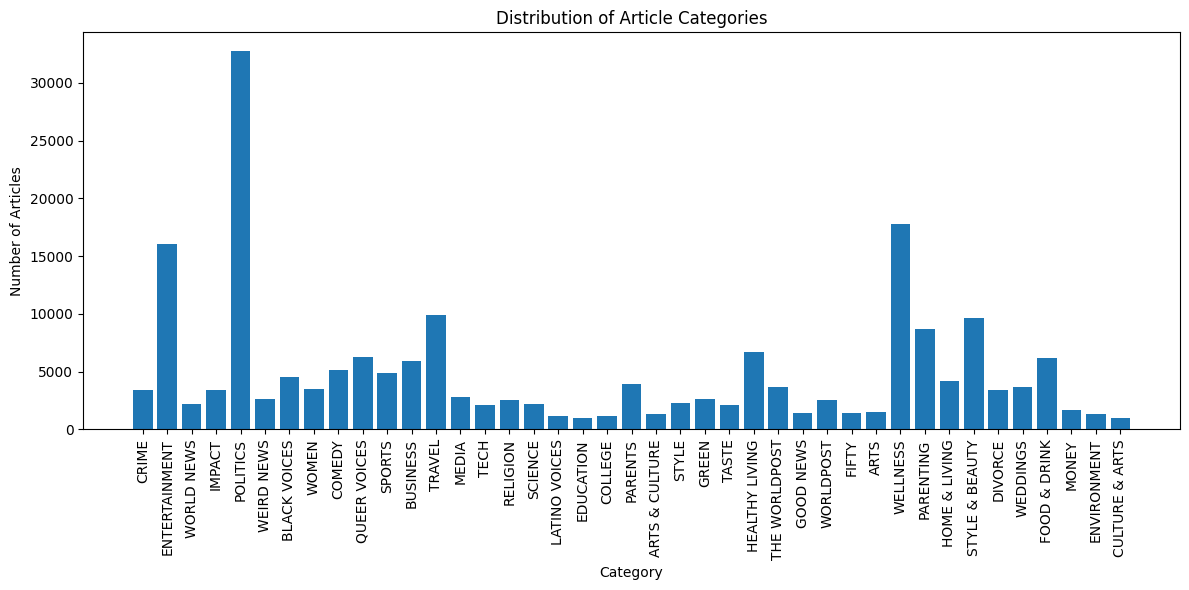

Documenting inconsistencies in the dataset:
Empty headlines: 6
Empty descriptions: 19712
Empty combined headline + description: 5
Duplicate articles: 488
Similar categories (one is a substring of the other):
  'ARTS' is a substring of 'ARTS & CULTURE'
  'ARTS' is a substring of 'CULTURE & ARTS'
  'STYLE' is a substring of 'STYLE & BEAUTY'
  'WORLDPOST' is a substring of 'THE WORLDPOST'

Manually identified similar categories:
  'POLITICS' and 'WORLD NEWS'
  'TECH' and 'SCIENCE'
  'ENTERTAINMENT' and 'ARTS & CULTURE'
  'PARENTING' AND 'PARENTS'


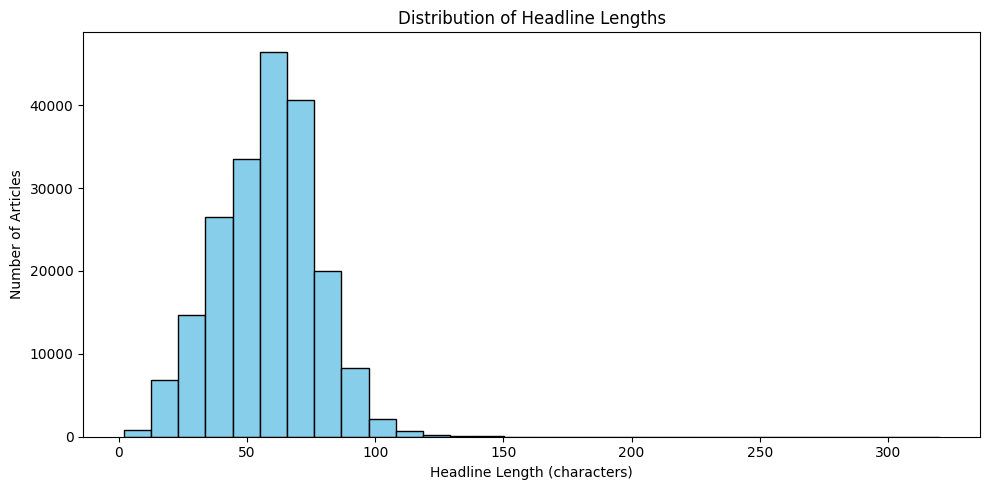

Average headline length: 57.94 characters
Median headline length: 59.00 characters


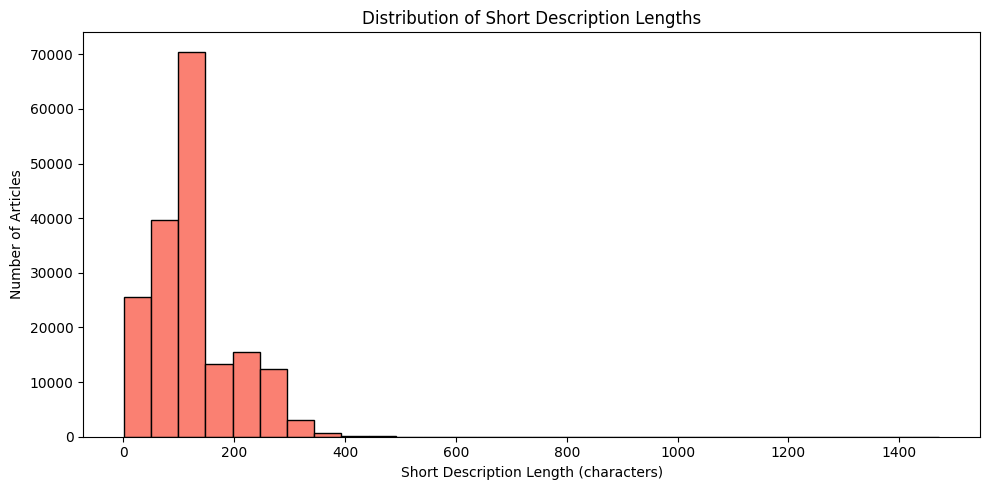

Average short description length: 126.75 characters
Median short description length: 121.00 characters
Unique words in headlines: 55690
Unique words in descriptions: 74090
Most common words in headlines:
  the: 62245
  to: 50488
  s: 40943
  a: 32267
  of: 32013
  in: 30489
  for: 24311
  and: 23978
  is: 17395
  on: 16614
  with: 13173
  trump: 12994
  you: 12817
  your: 10525
  photos: 10342
  how: 9354
  new: 8574
  at: 8538
  t: 8482
  from: 8196

Most common words in descriptions:
  the: 200171
  to: 114574
  a: 101972
  of: 96457
  and: 96325
  in: 65953
  s: 54344
  is: 49269
  that: 45949
  it: 43861
  i: 40965
  you: 40283
  for: 39982
  on: 31066
  we: 28655
  with: 27259
  are: 27070
  be: 23093
  this: 22188
  as: 21432
Least common words in headlines:
  texana: 1
  pbm: 1
  steelworkers: 1
  luvin: 1
  stahl: 1
  softie: 1
  sidebends: 1
  bernalda: 1
  kwong: 1
  sieber: 1
  ghats: 1
  nobbs: 1
  tinker: 1
  unsuitable: 1
  allard: 1
  hoorn: 1
  songline: 1
  aneesh: 1
 

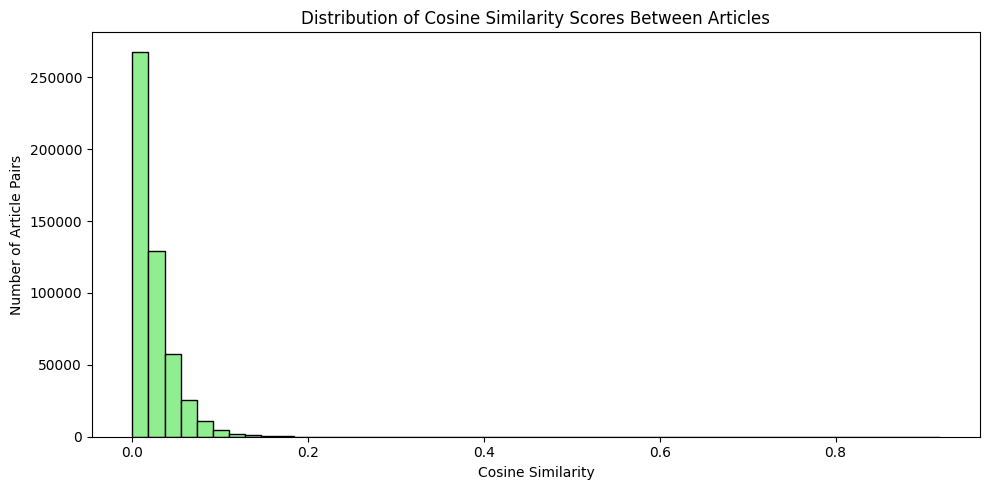

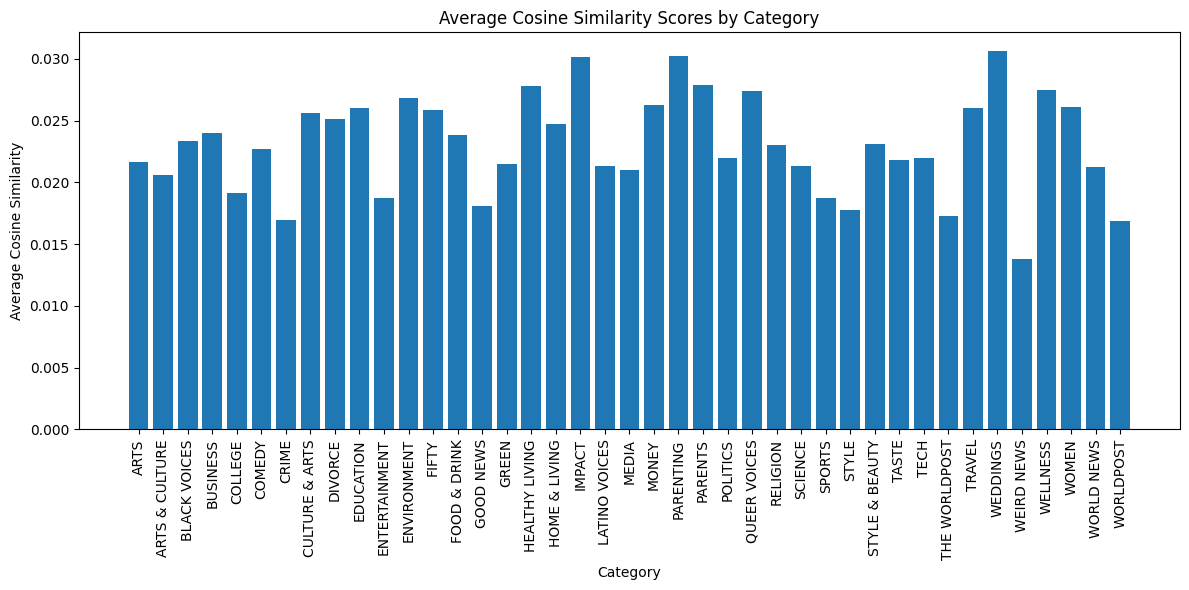

Average cosine similarity scores by category:
  ARTS: 0.0216
  ARTS & CULTURE: 0.0206
  BLACK VOICES: 0.0234
  BUSINESS: 0.0240
  COLLEGE: 0.0192
  COMEDY: 0.0227
  CRIME: 0.0170
  CULTURE & ARTS: 0.0256
  DIVORCE: 0.0251
  EDUCATION: 0.0260
  ENTERTAINMENT: 0.0188
  ENVIRONMENT: 0.0268
  FIFTY: 0.0259
  FOOD & DRINK: 0.0238
  GOOD NEWS: 0.0181
  GREEN: 0.0215
  HEALTHY LIVING: 0.0278
  HOME & LIVING: 0.0247
  IMPACT: 0.0301
  LATINO VOICES: 0.0213
  MEDIA: 0.0210
  MONEY: 0.0263
  PARENTING: 0.0302
  PARENTS: 0.0279
  POLITICS: 0.0220
  QUEER VOICES: 0.0274
  RELIGION: 0.0230
  SCIENCE: 0.0214
  SPORTS: 0.0187
  STYLE: 0.0178
  STYLE & BEAUTY: 0.0231
  TASTE: 0.0218
  TECH: 0.0220
  THE WORLDPOST: 0.0173
  TRAVEL: 0.0260
  WEDDINGS: 0.0306
  WEIRD NEWS: 0.0138
  WELLNESS: 0.0275
  WOMEN: 0.0261
  WORLD NEWS: 0.0213
  WORLDPOST: 0.0169
Number of similar but different category pairs: 10
Number of dissimilar but same category pairs: 27236


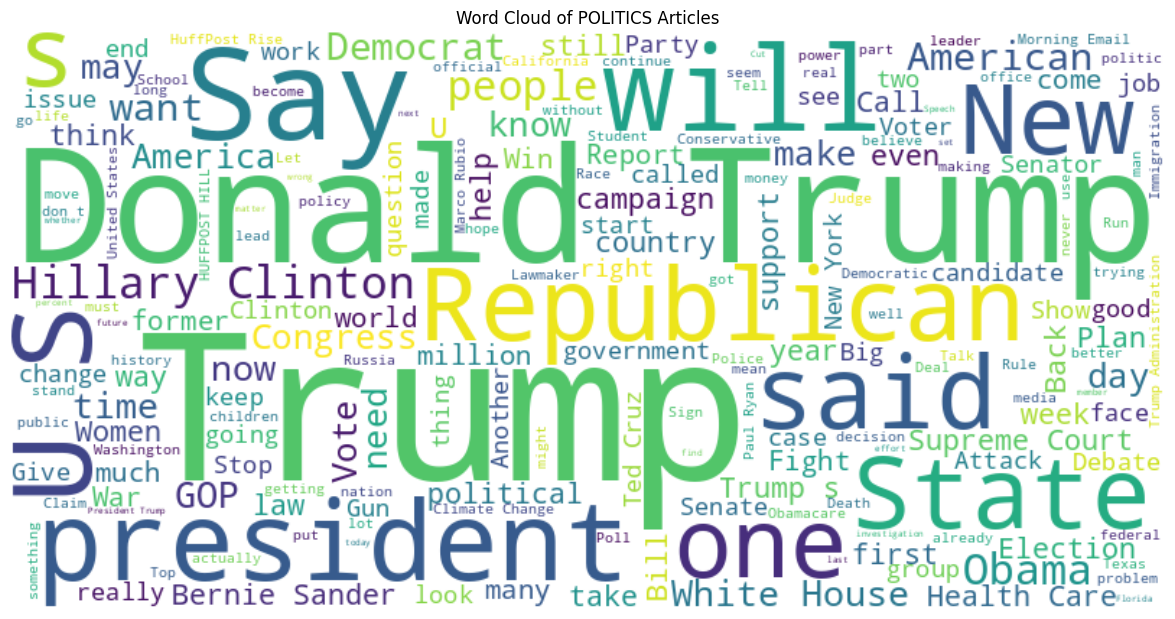

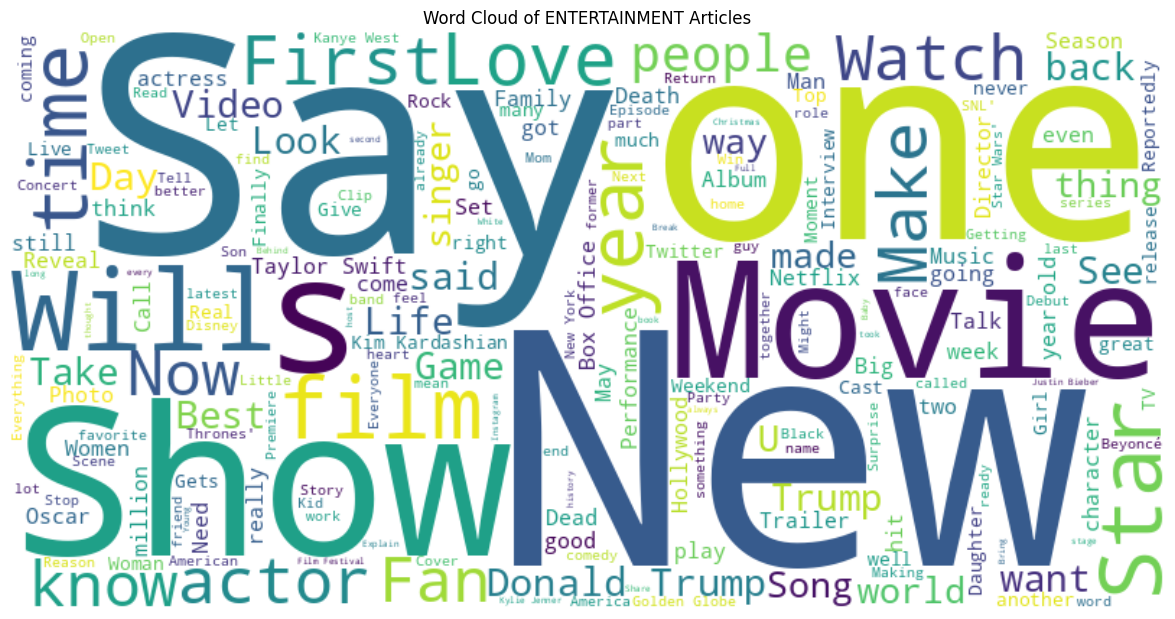

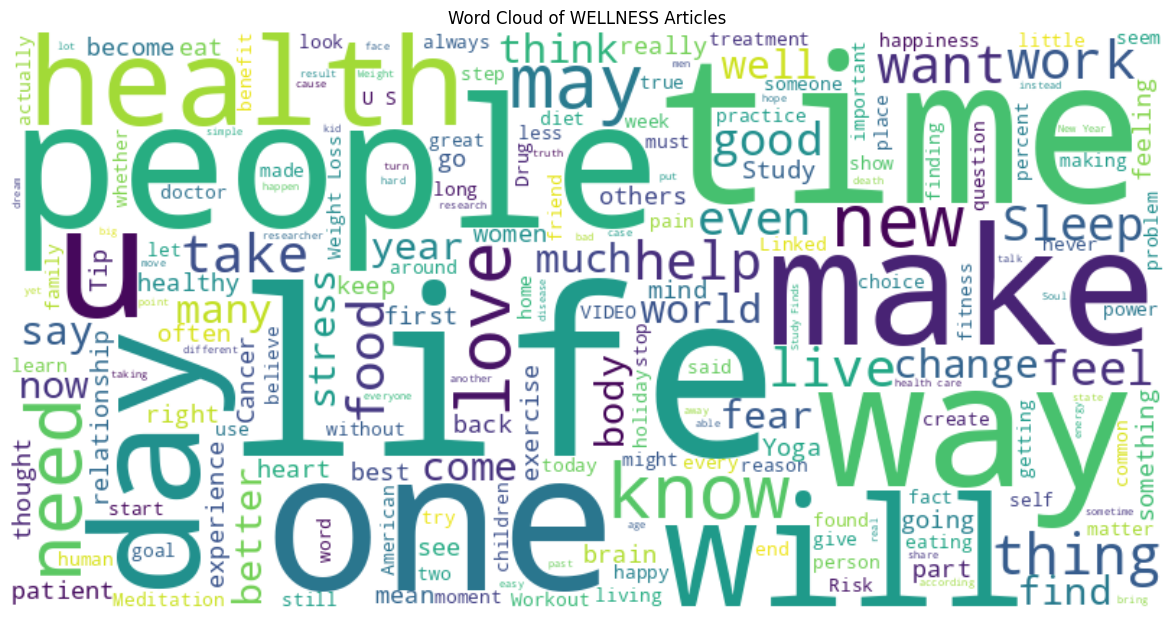

In [16]:
# Your code here, add as many cells as you like. Provide organization and structure by appropriate comments, labels, and variable names. Explain what
# you are doing in case you come back to this in a year. 

# Load the dataset from disk
huff_all = load_from_disk("huffpost_splits")

# Count number of articles and unique categories
total_articles = len(huff_all)
unique_categories = set(huff_all["category"])
print(f"Total articles: {total_articles}")
print(f"Unique categories: {len(unique_categories)}")
print("Categories:", unique_categories)

# Count the number of articles per category
category_counts = Counter(huff_all["category"])
print("Article counts by category:")
for category, count in category_counts.most_common():
    print(f"  {category}: {count}")
print("\n" * 2)

# Show 20 random examples of category, headline, and short description
print("Random examples:")
for example in huff_all.shuffle(seed=random_seed).select([i for i in list(range(20))]):
    print(f"Category: {example['category']}")
    print(f"Headline: {example['headline']}")
    print(f"Description: {example['short_description']}")
    print("-" * 80)

# Plot the distribution of article categories
plt.figure(figsize=(12, 6))
plt.bar(category_counts.keys(), category_counts.values())
plt.xticks(rotation=90)
plt.title("Distribution of Article Categories")
plt.xlabel("Category")
plt.ylabel("Number of Articles")
plt.tight_layout()
plt.show()

# Look for empty or missing values in the headline and short description columns
print("Documenting inconsistencies in the dataset:")
empty_headlines = sum(1 for ex in huff_all if not ex["headline"])
empty_descriptions = sum(1 for ex in huff_all if not ex["short_description"])
print(f"Empty headlines: {empty_headlines}")
print(f"Empty descriptions: {empty_descriptions}")

# Look for empty combined text (headline + description)
empty_combined = sum(1 for ex in huff_all if not (ex["headline"] or ex["short_description"]))
print(f"Empty combined headline + description: {empty_combined}")

# Look for duplicate articles based on headline and description
seen = set()
duplicates = 0
for ex in huff_all:
    key = (ex["headline"], ex["short_description"])
    if key in seen:
        duplicates += 1
    else:
        seen.add(key)
print(f"Duplicate articles: {duplicates}")

# Identifying categories that are very similar to each other
similar_categories = []
for cat1 in unique_categories:
    for cat2 in unique_categories:
        if cat1 != cat2 and cat1 in cat2:
            similar_categories.append((cat1, cat2)) # This checks if one category name is a substring of another
print("Similar categories (one is a substring of the other):")
for cat1, cat2 in similar_categories:
    print(f"  '{cat1}' is a substring of '{cat2}'")

# Manually identified similar categories that are not substrings but may have overlapping content
# For example, "POLITICS" and "WORLD NEWS" might have some overlap in content, even though they are not substrings of each other.
print("\nManually identified similar categories:")
print("  'POLITICS' and 'WORLD NEWS'")
print("  'TECH' and 'SCIENCE'")
print("  'ENTERTAINMENT' and 'ARTS & CULTURE'")
print("  'PARENTING' AND 'PARENTS'")

# Plot a histogram of headline lengths
headline_lengths = [len(ex["headline"]) for ex in huff_all if ex["headline"]]
plt.figure(figsize=(10, 5))
plt.hist(headline_lengths, bins=30, color='skyblue', edgecolor='black')
plt.title("Distribution of Headline Lengths")
plt.xlabel("Headline Length (characters)")
plt.ylabel("Number of Articles")
plt.tight_layout()
plt.show()

# Print average and median headline lengths
avg_headline_length = np.mean(headline_lengths)
median_headline_length = np.median(headline_lengths)
print(f"Average headline length: {avg_headline_length:.2f} characters")
print(f"Median headline length: {median_headline_length:.2f} characters")

# Plot a histogram of short description lengths
description_lengths = [len(ex["short_description"]) for ex in huff_all if ex["short_description"]]
plt.figure(figsize=(10, 5))
plt.hist(description_lengths, bins=30, color='salmon', edgecolor='black')
plt.title("Distribution of Short Description Lengths")
plt.xlabel("Short Description Length (characters)")
plt.ylabel("Number of Articles")
plt.tight_layout()
plt.show()

# Print average and median short description lengths
avg_description_length = np.mean(description_lengths)
median_description_length = np.median(description_lengths)
print(f"Average short description length: {avg_description_length:.2f} characters")
print(f"Median short description length: {median_description_length:.2f} characters")

# Print number of unique words in headlines and descriptions
from collections import Counter
import re

def tokenize(text):
    return re.findall(r'\b\w+\b', text.lower())

headline_words = Counter()
description_words = Counter()

for ex in huff_all:
    headline_words.update(tokenize(ex["headline"]))
    description_words.update(tokenize(ex["short_description"]))

print(f"Unique words in headlines: {len(headline_words)}")
print(f"Unique words in descriptions: {len(description_words)}")

# Examine the most common words in headlines and descriptions
print("Most common words in headlines:")
for word, count in headline_words.most_common(20):
    print(f"  {word}: {count}")
print("\nMost common words in descriptions:")
for word, count in description_words.most_common(20):
    print(f"  {word}: {count}")

# Examine the least common words in headlines and descriptions
print("Least common words in headlines:")
for word, count in headline_words.most_common()[-20:]:
    print(f"  {word}: {count}")
print("\nLeast common words in descriptions:")
for word, count in description_words.most_common()[-20:]:
    print(f"  {word}: {count}")

# Compute cosine similarity between two example articles based on concatenation of headlines and descriptions.
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

def article_to_text(ex):
    return (ex["headline"] or "") + "  [SEP]  " + (ex["short_description"] or "")

import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Use a fixed sample of 1000 articles
sample_size = min(1000, len(huff_all))
huff_sample = huff_all.shuffle(seed=random_seed).select(range(sample_size))

# Build text list from the sample only
article_texts = [article_to_text(ex) for ex in huff_sample]

# TF-IDF and cosine similarity on the sample only
vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(article_texts)
similarity_matrix = cosine_similarity(tfidf_matrix)

# Save category info from the sample only
sample_categories = [huff_sample[i]["category"] for i in range(sample_size)]
unique_categories = sorted(set(sample_categories))

# -----------------------------
# Most similar pair
# -----------------------------
similarity_for_max = similarity_matrix.copy()
np.fill_diagonal(similarity_for_max, -1)  # ignore self-similarity

most_similar_indices = np.unravel_index(
    np.argmax(similarity_for_max),
    similarity_for_max.shape
)

print(f"Most similar articles are at sample indices: {most_similar_indices}")
print("Article 1:")
print(f"  Category: {huff_sample[most_similar_indices[0]]['category']}")
print(f"  Headline: {huff_sample[most_similar_indices[0]]['headline']}")
print(f"  Description: {huff_sample[most_similar_indices[0]]['short_description']}")

print("\nArticle 2:")
print(f"  Category: {huff_sample[most_similar_indices[1]]['category']}")
print(f"  Headline: {huff_sample[most_similar_indices[1]]['headline']}")
print(f"  Description: {huff_sample[most_similar_indices[1]]['short_description']}")

# -----------------------------
# Most dissimilar pair
# -----------------------------
similarity_for_min = similarity_matrix.copy()
np.fill_diagonal(similarity_for_min, 2)  # make diagonal impossible to be the minimum

most_dissimilar_indices = np.unravel_index(
    np.argmin(similarity_for_min),
    similarity_for_min.shape
)

print(f"\nMost dissimilar articles are at sample indices: {most_dissimilar_indices}")
print("Article 1:")
print(f"  Category: {huff_sample[most_dissimilar_indices[0]]['category']}")
print(f"  Headline: {huff_sample[most_dissimilar_indices[0]]['headline']}")
print(f"  Description: {huff_sample[most_dissimilar_indices[0]]['short_description']}")

print("\nArticle 2:")
print(f"  Category: {huff_sample[most_dissimilar_indices[1]]['category']}")
print(f"  Headline: {huff_sample[most_dissimilar_indices[1]]['headline']}")
print(f"  Description: {huff_sample[most_dissimilar_indices[1]]['short_description']}")

# -----------------------------
# Histogram of cosine similarity scores
# Only use unique article pairs, not the full matrix
# -----------------------------
similarity_scores = similarity_matrix[np.triu_indices(sample_size, k=1)]

plt.figure(figsize=(10, 5))
plt.hist(similarity_scores, bins=50, color="lightgreen", edgecolor="black")
plt.title("Distribution of Cosine Similarity Scores Between Articles")
plt.xlabel("Cosine Similarity")
plt.ylabel("Number of Article Pairs")
plt.tight_layout()
plt.show()

# -----------------------------
# Average cosine similarity by category
# This groups rows by the article's own category
# -----------------------------
category_similarities = {category: [] for category in unique_categories}

for i in range(sample_size):
    category_name = huff_sample[i]["category"]
    row_without_self = np.delete(similarity_matrix[i], i)
    category_similarities[category_name].extend(row_without_self)

avg_similarities = {
    category: np.mean(scores) if len(scores) > 0 else 0
    for category, scores in category_similarities.items()
}

plt.figure(figsize=(12, 6))
plt.bar(avg_similarities.keys(), avg_similarities.values())
plt.xticks(rotation=90)
plt.title("Average Cosine Similarity Scores by Category")
plt.xlabel("Category")
plt.ylabel("Average Cosine Similarity")
plt.tight_layout()
plt.show()

print("Average cosine similarity scores by category:")
for category, avg_score in avg_similarities.items():
    print(f"  {category}: {avg_score:.4f}")

# -----------------------------
# Edge cases
# Similar articles in different categories
# Dissimilar articles in the same category
# -----------------------------
similar_but_different = []
dissimilar_but_same = []

for i in range(sample_size):
    for j in range(i + 1, sample_size):
        category_i = huff_sample[i]["category"]
        category_j = huff_sample[j]["category"]
        similarity_score = similarity_matrix[i, j]

        if category_i != category_j and similarity_score > 0.3:
            similar_but_different.append((i, j))
        elif category_i == category_j and similarity_score < 0.2:
            dissimilar_but_same.append((i, j))

print(f"Number of similar but different category pairs: {len(similar_but_different)}")
print(f"Number of dissimilar but same category pairs: {len(dissimilar_but_same)}")

# Generate a word cloud of the most common words in articles from the "POLITICS" category
politics_text = " ".join(ex["headline"] + " " + ex["short_description"] for ex in huff_all if ex["category"] == "POLITICS")
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(politics_text)
plt.figure(figsize=(15, 7.5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud of POLITICS Articles")
plt.show()

# Generate a word cloud of the most common words in articles from the "ENTERTAINMENT" category
entertainment_text = " ".join(ex["headline"] + " " + ex["short_description"] for ex in huff_all if ex["category"] == "ENTERTAINMENT")
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(entertainment_text)
plt.figure(figsize=(15, 7.5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud of ENTERTAINMENT Articles")
plt.show()

# Generate a word cloud of the most common words in articles from the "WELLNESS" category
wellness_text = " ".join(ex["headline"] + " " + ex["short_description"] for ex in huff_all if ex["category"] == "WELLNESS")
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(wellness_text)
plt.figure(figsize=(15, 7.5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud of WELLNESS Articles")
plt.show()


### Graded Questions (2 pts each)

For each question, answer thoroughly but concisely, in a short paragraph, longer or shorter as needed. Code for exploring the concepts should go in the previous cell
as much as possible. 

1. **Dataset Summary:**  
   Describe your chosen dataset  (as if explaining to your *clueless boss* what you are working on).
   - State which dataset you are going to use.   
   - What kind of data does it contain (images or text)?  
   - How many samples and classes are there?  
   - What is the task you’ll perform (classification into what categories)?
   - What is the potential business use for this dataset?

1.1. **Your answer here:**



2. **Initial Observations:**  
   What stood out to you from your EDA?  
   - Did you notice any imbalanced or ambiguous classes?  
   - Any patterns, anomalies, or potential sources of bias?  
   - For images: note any variation in lighting, composition, or color.  
   - For text: mention redundancy, topic overlap, or very short examples.

1.2. **Your answer here:**



3. **Challenges & Implications:**  
   Based on your inspection, what challenges might affect model performance or training (e.g., imbalance, ambiguous labels, variable quality)?  

1.3. **Your answer here:**



4. **Preparation Ideas:**  
   What data-cleaning or preprocessing steps might help address these issues?  
   (You will not implement these yet—just describe what you might do later.)

1.4. **Your answer here:**



5. **Reflection:**  
   Why did you choose this dataset over the other one?  
   - What makes it more interesting, realistic, or relevant for you?  
   - What do you expect to learn from working with it?

1.5. **Your answer here:**



## Problem 2 – Frame the Problem (15 pts)

#### Objective

Identify the **key challenges** in your chosen dataset and outline **practical solutions** you would try, plus how you’ll **evaluate** them later.

#### Steps to follow

1. **Diagnose likely challenges (from your EDA):**

   Examples:
   * **Class imbalance:**
     Report label counts and an imbalance ratio (max / median). List any minority classes.
   * **Length/size variance:**
     For text, show length percentiles (50/75/90/95) and estimate truncation rate at candidate `max_text_length`s (e.g., 256/300/512). For images, summarize native resolutions.
   * **Noise/duplicates/leakage:**
     Note empty or malformed items, near-duplicates, and how you would prevent cross-split leakage.
   * **Ambiguous/overlapping labels:**
     Give 2–3 example pairs you expect to be confusable and why.
   * **Compute constraints:**
     Briefly state limits (RAM/GPU/CPU) that might affect batch size, sequence length, or image size.

2. **Map each challenge to a concrete solution plan:**

   Examples:
   * **Imbalance →** `class_weight` or oversampling; report which one you’d try first and why.
   * **Length/size →** pick a target `max_text_length` (e.g., 95th percentile) with masking; for images, standardize resize/crop and basic augmentation.
   * **Noise/duplicates →** dedupe (hash/near-dup), drop empty/very short items, document any relabeling.
   * **Ambiguity →** consider merging labels (if justified), or add features (bigrams/char-ngrams; simple image augmentations).
   * **Overfitting risk →** early stopping on your primary metric, dropout/weight decay, freeze-then-finetune plan (for pretrained features).

3. **Explore appropriate evaluation metrics:**

   Examples:
   * **Primary metric:** pick one aligned to your data (e.g., **macro-F1** if imbalanced; accuracy if balanced).
   * **Secondary metric(s):** per-class precision/recall, confusion matrix.
   * **Protocol:** stratified Train/Val/Test (e.g., 70/15/15), fixed seed, leakage checks.

4. **Answer the graded questions below.**



In [17]:
# Your code here, add as many cells as you like. Provide organization and structure by appropriate comments, labels, and variable names. Explain what
# you are doing in case you come back to this in a year. 

# Report label counts and an imbalance ratio (max / median)
label_counts = Counter(huff_all["category"])
max_count = max(label_counts.values())
median_count = np.median(list(label_counts.values()))
imbalance_ratio = max_count / median_count if median_count > 0 else 0
print(f"Label counts: {label_counts}")
print(f"Imbalance ratio (max / median): {imbalance_ratio:.2f}")
print("\n" * 2)

# List minority classes (those with counts less than 10% of the max count)
minority_classes = [category for category, count in label_counts.items() if count < 0.1 * max_count]
print("Minority classes (less than 10% of max count):")
for category in minority_classes:
    print(f"  {category}: {label_counts[category]} articles")

print("\n" * 2)

# Show length percentiles for combined headline + description text
combined_lengths = [len(article_to_text(ex)) for ex in huff_all]
percentiles = [0, 25, 50, 75, 90, 95, 99, 100]
length_percentiles = np.percentile(combined_lengths, percentiles)
print("Combined headline + description length percentiles:")
for p, length in zip(percentiles, length_percentiles):
    print(f"  {p}th percentile: {length} characters")
print("\n" * 2)

# Estimate truncation rate at candidate max input lengths (256, 300, 512)
candidate_lengths = [256, 300, 512]
for max_len in candidate_lengths:
    truncation_count = sum(1 for length in combined_lengths if length > max_len)
    truncation_rate = truncation_count / len(combined_lengths)
    print(f"Truncation rate at max length {max_len}: {truncation_rate:.2%} ({truncation_count} articles)")
print("\n" * 2)

# Note empty and very short articles that may not provide enough signal for training
short_articles = sum(1 for length in combined_lengths if length < 20)
print(f"Number of articles with combined length < 20 characters: {short_articles}")
print("\n" * 2)

# Note near duplicate articles that may cause data leakage if not handled properly
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Use a fixed sample of 1000 articles for similarity analysis
sample_size = min(1000, len(huff_all))
huff_sample = huff_all.shuffle(seed=random_seed).select(range(sample_size))
article_texts = [article_to_text(ex) for ex in huff_sample]
vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(article_texts)
similarity_matrix = cosine_similarity(tfidf_matrix)
similarity_for_max = similarity_matrix.copy()
np.fill_diagonal(similarity_for_max, -1)  # ignore self-similarity
most_similar_indices = np.unravel_index(
    np.argmax(similarity_for_max),
    similarity_for_max.shape
)
most_similar_score = similarity_matrix[most_similar_indices]
print(f"Most similar articles have cosine similarity of {most_similar_score:.4f} at sample indices {most_similar_indices}")
print("Article 1:")
print(f"  Category: {huff_sample[most_similar_indices[0]]['category']}")
print(f"  Headline: {huff_sample[most_similar_indices[0]]['headline']}")
print(f"  Description: {huff_sample[most_similar_indices[0]]['short_description']}")
print("\nArticle 2:")
print(f"  Category: {huff_sample[most_similar_indices[1]]['category']}")
print(f"  Headline: {huff_sample[most_similar_indices[1]]['headline']}")
print(f"  Description: {huff_sample[most_similar_indices[1]]['short_description']}")
print("\n" * 2)

# Identify potential data leakage issues, such as articles with the same headline but different descriptions, or vice versa
headline_to_descriptions = {}
for ex in huff_all:
    headline = ex["headline"]
    description = ex["short_description"]
    if headline in headline_to_descriptions:
        headline_to_descriptions[headline].add(description)
    else:
        headline_to_descriptions[headline] = {description}

potential_leakage = {headline: descs for headline, descs in headline_to_descriptions.items() if len(descs) > 1}
print(f"Number of headlines with multiple descriptions: {len(potential_leakage)}")
for headline, descs in list(potential_leakage.items())[:5]:  # show 5 examples
    print(f"Headline: {headline}")
    for desc in descs:
        print(f"  Description: {desc}")
    print("-" * 80)
print("\n" * 2)

# Identify 10 pairs of articles that are similar but have different categories, which could be edge cases for the model to learn from
similar_but_different = []
for i in range(sample_size):
    for j in range(i + 1, sample_size):
        category_i = huff_sample[i]["category"]
        category_j = huff_sample[j]["category"]
        similarity_score = similarity_matrix[i, j]
        if category_i != category_j and similarity_score > 0.3:
            similar_but_different.append((i, j, similarity_score))
print(f"Number of similar but different category pairs: {len(similar_but_different)}")
print("Examples of similar but different category pairs:")
for i, (idx1, idx2, score) in enumerate(similar_but_different[:10]):
    print(f"Pair {i+1} with cosine similarity {score:.4f}:")
    print(f"  Article 1 (Category: {huff_sample[idx1]['category']}):")
    print(f"    Headline: {huff_sample[idx1]['headline']}")
    print(f"    Description: {huff_sample[idx1]['short_description']}")
    print(f"  Article 2 (Category: {huff_sample[idx2]['category']}):")
    print(f"    Headline: {huff_sample[idx2]['headline']}")
    print(f"    Description: {huff_sample[idx2]['short_description']}")
    print("-" * 80)

Label counts: Counter({'POLITICS': 32739, 'WELLNESS': 17827, 'ENTERTAINMENT': 16058, 'TRAVEL': 9887, 'STYLE & BEAUTY': 9649, 'PARENTING': 8677, 'HEALTHY LIVING': 6694, 'QUEER VOICES': 6314, 'FOOD & DRINK': 6226, 'BUSINESS': 5937, 'COMEDY': 5175, 'SPORTS': 4884, 'BLACK VOICES': 4528, 'HOME & LIVING': 4195, 'PARENTS': 3955, 'THE WORLDPOST': 3664, 'WEDDINGS': 3651, 'WOMEN': 3490, 'IMPACT': 3459, 'DIVORCE': 3426, 'CRIME': 3405, 'MEDIA': 2815, 'WEIRD NEWS': 2670, 'GREEN': 2622, 'WORLDPOST': 2579, 'RELIGION': 2556, 'STYLE': 2254, 'SCIENCE': 2178, 'WORLD NEWS': 2177, 'TASTE': 2096, 'TECH': 2082, 'MONEY': 1707, 'ARTS': 1509, 'FIFTY': 1401, 'GOOD NEWS': 1398, 'ARTS & CULTURE': 1339, 'ENVIRONMENT': 1323, 'COLLEGE': 1144, 'LATINO VOICES': 1129, 'CULTURE & ARTS': 1030, 'EDUCATION': 1004})
Imbalance ratio (max / median): 9.61



Minority classes (less than 10% of max count):
  WORLD NEWS: 2177 articles
  WEIRD NEWS: 2670 articles
  MEDIA: 2815 articles
  TECH: 2082 articles
  RELIGION: 2556 article

### Graded Questions (3 pts each)

For each question, answer thoroughly but concisely, in a short paragraph, longer or shorter as needed. Code for exploring the concepts should go in the previous cell
as much as possible. 

1. **State the prediction task**  
   - Describe what your model will predict (the *label*).  
   - *Examples:*  
     - “Given a photo of food, predict which of 101 categories it belongs to.”  
     - “Given a news headline + summary, predict its topical category.”  

2.1. **Your answer here:**

2. **Define inputs and outputs**  
   - *Inputs:* what information the model receives (e.g., pixel data, tokenized text).  
   - *Outputs:* the categorical label the model will predict.  

2.2. **Your answer here:**



3. **Identify possible challenges**  
   - Imbalanced classes, noisy data, ambiguous labels, overlapping features, or missing data  
   - *Images:* variation in lighting, color, composition, or size.  
   - *Text:* class imbalance, duplicate stories, short or ambiguous headlines.  

2.3. **Your answer here:**



4. **Propose how you will prepare or improve the data to address the challenges**  
   - *Images:* resizing, normalization, data augmentation (flips, rotations, brightness, color jitter).  
   - *Text:* tokenization, stop-word removal, TF-IDF, class balancing, embeddings (choose an embedding approach and specify its vector size). 

2.4. **Your answer here:**



5. **Specify success metrics**  
   - Identify the metrics you plan to use to evaluate model performance—typically **accuracy** and/or **F1-score**, which are standard for classification tasks.  
   - Briefly explain **why** these metrics are appropriate for your dataset and goal. For instance, accuracy may suffice for well-balanced datasets, while F1-score better reflects performance when some classes are under-represented.
   - If your dataset is **imbalanced**, consider computing **per-class metrics** (e.g., precision, recall, or F1 for each label) or **macro-averaged** scores, which give equal weight to each class regardless of its size—ensuring that minority classes are evaluated fairly.
In some cases, weighted averages (which weight classes by their frequency) or **confusion matrices** can also provide useful insight.
> You haven't run any models yet, and we haven’t studied every possible metric, but you’re encouraged to ask your favorite generative AI tool which evaluation metrics might best fit your dataset!
   - Clearly state how you will interpret success—for example, “Our goal is to achieve at least 80% overall accuracy without large per-class disparities.”

2.5. **Your answer here:**



### Final Question: Describe what use you made of generative AI tools in preparing this Milestone. 

**AI Question: Your answer here:**

---

## Appendix: A quick guide to Hugging Face Datasets

#### 1) What are they?

* A **table-like** dataset: rows = examples, columns = named fields (e.g., `"image"`, `"label"`, `"headline"`).
* Backed by **Apache Arrow** → fast, memory-efficient, lazy transforms.
* Two core objects:

  * `Dataset` — one table of rows/columns.
  * `DatasetDict` — a dict of splits, e.g. `{"train": Dataset, "val": Dataset, "test": Dataset}`.


#### 2) Load and inspect

```python
from datasets import load_dataset

# Food-101 (images)
food = load_dataset("food101", split="train+validation")  # both splits at once
len(food), food.column_names, food.features
# -> (≈101000, ['image','label'], {'label': ClassLabel(num_classes=101, names=[...])})

# Access by name (not by numeric column index!)
row0 = food[0]
img0, y0 = row0["image"], row0["label"]     # PIL image, int id
label_names = food.features["label"].names
label_names[y0]
```

For text (HuffPost JSON mirror):

```python
url = "https://huggingface.co/datasets/khalidalt/HuffPost/resolve/main/News_Category_Dataset_v2.json"
huff = load_dataset("json", data_files=url, split="train")
huff.column_names  # e.g. ['headline','short_description','category','authors','link','date']
```


#### 3) Common transforms

`Dataset`s are **immutable**: ops return a new dataset.

* **Map** (add/modify columns):

```python
def mk_text(ex):
    h = (ex.get("headline") or "").strip()
    s = (ex.get("short_description") or "").strip()
    return {"text": (h + " [SEP] " + s).strip()}

huff = huff.map(mk_text)  # adds 'text' column
```

* **Class-encode** labels (strings → integers with a vocabulary):

```python
from datasets.features import ClassLabel
if not isinstance(huff.features["category"], ClassLabel):
    huff = huff.class_encode_column("category")  # now ints with .names
```

* **Filter / select / rename / drop**:

```python
small = huff.select(range(5000))  # first 5k rows
huff = huff.remove_columns(["authors","link","date"])
huff = huff.rename_column("category", "label")
```


#### 4) Splitting & shuffling

```python
# Stratified 80/10/10 on Food-101 by 'label'
from datasets import DatasetDict
label_col = "label"

tmp = food.train_test_split(test_size=0.10, seed=42, stratify_by_column=label_col)
train_val = tmp["train"].train_test_split(test_size=1/9, seed=42, stratify_by_column=label_col)
ds = DatasetDict(train=train_val["train"], val=train_val["test"], test=tmp["test"])

len(ds["train"]), len(ds["val"]), len(ds["test"])
```

* `train_test_split` is **random by default** (reproducible with `seed=`).
* You typically **don’t need to pre-shuffle** datasets if your training dataloader already shuffles each epoch.


#### 5) Working with images

Use `with_transform` to apply on-the-fly resizing/augmentation and return tensors:

```python
import torchvision.transforms as T
from torch.utils.data import DataLoader
import torch, math, random

IM_SIZE = 224
train_tfms = T.Compose([T.RandomResizedCrop(IM_SIZE), T.RandomHorizontalFlip(), T.ToTensor()])
eval_tfms  = T.Compose([T.Resize(256), T.CenterCrop(IM_SIZE), T.ToTensor()])

def add_pixel_values(ex, tfms):  # ex['image'] -> ex['pixel_values']
    ex = dict(ex); ex["pixel_values"] = tfms(ex["image"]); return ex

train_t = ds["train"].with_transform(lambda ex: add_pixel_values(ex, train_tfms))
val_t   = ds["val"].with_transform(lambda ex: add_pixel_values(ex, eval_tfms))

def collate(batch):
    return {"pixel_values": torch.stack([b["pixel_values"] for b in batch]),
            "labels": torch.tensor([b["label"] for b in batch])}

train_loader = DataLoader(train_t, batch_size=64, shuffle=True,  collate_fn=collate)
val_loader   = DataLoader(val_t,   batch_size=64, shuffle=False, collate_fn=collate)
```

### 6) Working with Text

You can preprocess and tokenize text datasets using either a **transformer tokenizer** or a **linguistic pipeline like spaCy**, depending on your model type and goals.


#### Option A: Transformer Tokenizer (for fine-tuning models like BERT or DistilBERT)

Use a pretrained tokenizer with the Hugging Face `map` method to efficiently process your dataset in batches:

```python
from transformers import AutoTokenizer

tok = AutoTokenizer.from_pretrained("distilbert-base-uncased")

def tokenize(batch):
    return tok(batch["text"], truncation=True, padding="max_length", max_length=128)

tokenized = huff.map(
    tokenize,
    batched=True,
    remove_columns=[c for c in huff.column_names if c not in ("category", "label")]
)
```

This produces token IDs, attention masks, and other fields expected by transformer models.
Use this approach if your project involves fine-tuning pretrained language models.


#### Option B: spaCy Tokenization and Cleaning (for classical ML or custom preprocessing)

If you are **not using transformers**, or if you want to explore feature engineering (e.g., TF-IDF, word frequency, or embedding averages), you can preprocess text with **spaCy** instead.

```python
# !pip install spacy
# !python -m spacy download en_core_web_sm

import spacy
from datasets import load_dataset

nlp = spacy.load("en_core_web_sm", disable=["ner", "parser", "textcat"])
STOP = spacy.lang.en.stop_words.STOP_WORDS

def spacy_clean(batch):
    docs = list(nlp.pipe(batch["text"], batch_size=1000))
    cleaned = []
    for doc in docs:
        tokens = [t.lemma_.lower() for t in doc if t.is_alpha and not t.is_stop]
        cleaned.append(" ".join(tokens))
    return {"text_clean": cleaned, "len_tokens": [len(c.split()) for c in cleaned]}

huff = huff.map(
    spacy_clean,
    batched=True,
    batch_size=1000,
    remove_columns=[c for c in huff.column_names if c not in ("category", "label")]
)
```

The resulting column `text_clean` can be used with:

* `TfidfVectorizer` (Scikit-learn)
* `TextVectorization` (Keras)
* or any other custom embedding method.

> 💡 **Tip:** spaCy is ideal for lightweight NLP pipelines or for models that rely on explicit preprocessing (lemmatization, stopword removal). Transformer tokenizers, by contrast, expect *raw text* and handle subword tokenization internally.



#### 7) Slicing, concatenating, saving

```python
# Slicing
head_1000 = food.select(range(1000))
tail_10pct = food.select(range(int(0.9*len(food)), len(food)))

# Concatenate splits/datasets
from datasets import concatenate_datasets
all_train = concatenate_datasets([ds["train"], ds["val"]])

# Save / reload
ds.save_to_disk("food101_splits")
from datasets import load_from_disk
ds2 = load_from_disk("food101_splits")
```


#### 8) Quick “gotchas”

* **Columns by name** (strings), not numeric indices.
* Avoid converting huge columns to `list(...)` unless necessary; prefer vectorized ops with `map`, `filter`, `select`.
* `PYTHONHASHSEED` must be set **before** the Python process starts to matter; use explicit `seed=` arguments for reproducibility.
* Datasets print **previews** (e.g., `Column([6, 6, 6, ...])` is just the first few values).


#### 9) A minimal checklist to follow

1. `load_dataset(...)` → confirm `column_names`, `features`.
2. Build any needed columns (`"text"`), and **class-encode** labels if strings.
3. Make a **stratified 80/10/10** split (`train_test_split` ×2).
4. Do **EDA**: class counts, sample printouts or image grids.
5. For training:

   * **images** → `with_transform` + DataLoader
   * **text** → tokenizer via `.map(...)` + trainer/model pipeline
6. Save your `DatasetDict` with `save_to_disk(...)` (optional for text but handy, **don't** use it for big image datasets).

